In [72]:
import pandas as pd

df = pd.read_excel("../data/Product-Sales-Region-Cleaned.xlsx")
df.to_csv("../data/Product-Sales-Region.csv", index=False)

df.head()


,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Promotion,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.40,Online,FREESHIP,No,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.01,Gift Card,SAVE10,No,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.87,Online,WINTER15,No,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.75,Gift Card,FREESHIP,No,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.68,Online,SAVE10,No,REG100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric


In [73]:
from pathlib import Path

Path("../output/charts").mkdir(parents=True, exist_ok=True)
Path("../output/summary").mkdir(parents=True, exist_ok=True)

In [74]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1500 non-null   datetime64[ns]
 1   Region         1500 non-null   object        
 2   Product        1500 non-null   object        
 3   Quantity       1500 non-null   int64         
 4   UnitPrice      1500 non-null   float64       
 5   StoreLocation  1500 non-null   object        
 6   CustomerType   1500 non-null   object        
 7   Discount       1500 non-null   float64       
 8   Salesperson    1500 non-null   object        
 9   TotalPrice     1500 non-null   float64       
 10  PaymentMethod  1500 non-null   object        
 11  Promotion      1500 non-null   object        
 12  Returned       1500 non-null   object        
 13  OrderID        1500 non-null   object        
 14  CustomerName   1500 non-null   object        
 15  ShippingCost   1500 n

In [75]:

df["TotalPrice"].mean()


np.float64(2919.9949333333334)

In [76]:
df["TotalPrice"].median()

2174.725

In [77]:
df["TotalPrice"].count()

np.int64(1500)

In [78]:
#Analyze sales patterns; Total sales by region

df.groupby("Region")["TotalPrice"].sum().sort_values(ascending=False)


Region
North      967958.04
East       883633.72
West       853478.85
Central    847153.66
South      827768.13
Name: TotalPrice, dtype: float64

In [79]:
# Top selling products
df.groupby("Product")["Quantity"].sum().sort_values(ascending= False)

Product
Tablet     2577
Laptop     2408
Printer    2336
Monitor    2177
Chair      2122
Desk       2026
Phone      1970
Name: Quantity, dtype: int64

In [80]:
# Sales by customer type
df.groupby("CustomerType")["TotalPrice"].sum()

CustomerType
Retail       2195525.57
Wholesale    2184466.83
Name: TotalPrice, dtype: float64

In [81]:
# Sales trend by date
df.groupby("Date")["TotalPrice"].sum()

Date
2023-01-01     9631.07
2023-01-02      365.75
2023-01-04     5608.60
2023-01-05    15796.93
2023-01-06     1460.07
                ...   
2025-06-24      584.63
2025-06-27     1774.77
2025-06-28     3772.25
2025-06-29     7867.13
2025-06-30    20160.09
Name: TotalPrice, Length: 747, dtype: float64

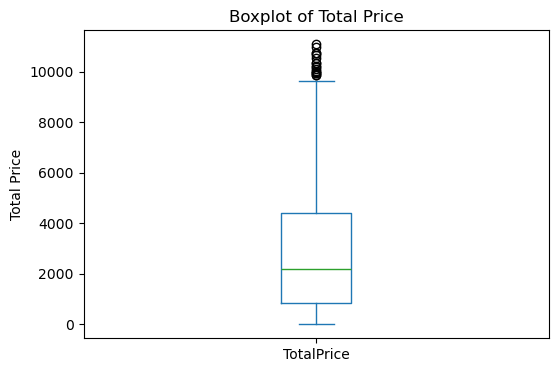

In [82]:
# Find outliers in TotalPrice using boxplot

import matplotlib.pyplot as plt
from pathlib import Path

# create output folder if not exists
Path("../output/charts").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6,4))
df["TotalPrice"].plot(kind="box")

plt.title("Boxplot of Total Price")
plt.ylabel("Total Price")

# save chart to output folder
plt.savefig("../output/charts/total_price_boxplot.png", bbox_inches="tight")

plt.show()

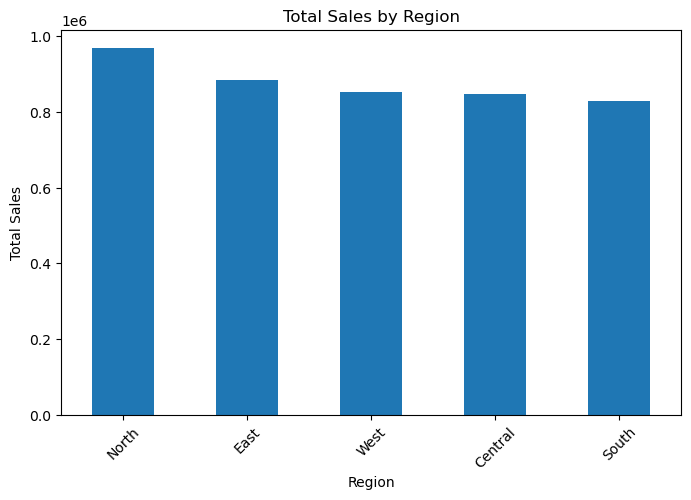

In [83]:
# Create chart: Total Sales by Region

import matplotlib.pyplot as plt
from pathlib import Path

# create output folder
Path("../output/charts").mkdir(parents=True, exist_ok=True)

sales_by_region = df.groupby("Region")["TotalPrice"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sales_by_region.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.savefig("../output/charts/sales_by_region.png", bbox_inches="tight")
plt.show()

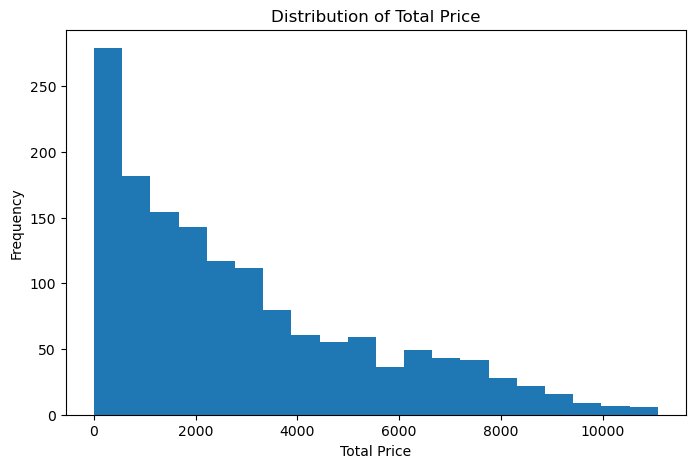

In [84]:
# Create chart: Distribution of Total Price

import matplotlib.pyplot as plt
from pathlib import Path

# create output folder
Path("../output/charts").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,5))

df["TotalPrice"].plot(kind="hist", bins=20)

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.savefig("../output/charts/total_price_distribution.png", bbox_inches="tight")
plt.show()

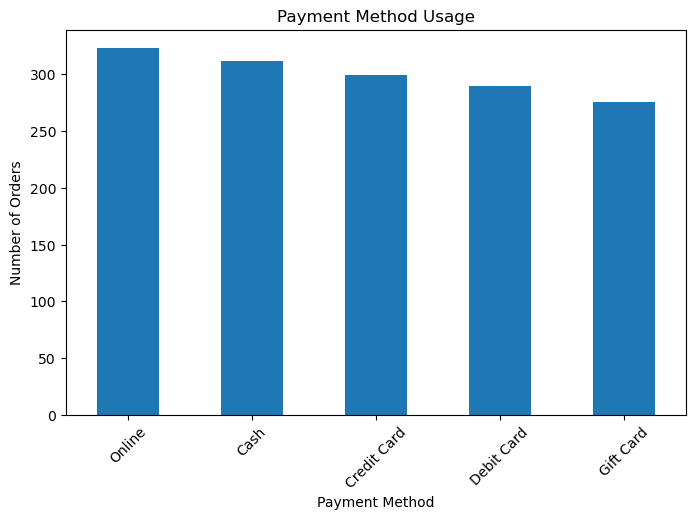

In [85]:
# Create chart: Payment Method Usage

import matplotlib.pyplot as plt
from pathlib import Path

# create output folder
Path("../output/charts").mkdir(parents=True, exist_ok=True)

payment_method_usage = df.groupby("PaymentMethod")["OrderID"].count().sort_values(ascending=False)

plt.figure(figsize=(8,5))
payment_method_usage.plot(kind="bar")

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.savefig("../output/charts/payment_method_usage.png", bbox_inches="tight")
plt.show()

## Key Observations

1. The highest total sales were recorded in the North region.
2. The lowest total sales were recorded in the South region.
3. Some TotalPrice values appear as outliers, meaning there are unusual high  value transactions.
4. Payment method usage shows which method customers prefer the most.
5. Product wise analysis helps identify the products that generate the highest revenue.
6. Sales trend analysis helps understand how sales change over time.

## Recommendations

1. Focus more marketing and sales strategies on low performing regions.
2. Maintain enough stock for high performing products.
3. Investigate outliers before removing them because they may be valid high value purchases.
4. Analyze customer type and payment method patterns for better business decisions.

In [86]:
# Total sales by product
sales_by_product = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)

sales_by_product

Product
Tablet     684539.36
Laptop     684417.21
Printer    684387.43
Monitor    651629.35
Chair      622589.53
Desk       555266.66
Phone      497162.86
Name: TotalPrice, dtype: float64

In [87]:
from pathlib import Path
import pandas as pd

# create summary folder
Path("../output/summary").mkdir(parents=True, exist_ok=True)

# create required variables
sales_by_region = df.groupby("Region")["TotalPrice"].sum().sort_values(ascending=False)
sales_by_product = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)
payment_method_usage = df.groupby("PaymentMethod")["OrderID"].count().sort_values(ascending=False)

summary = {
    "Total Records": len(df),
    "Total Sales": df["TotalPrice"].sum(),
    "Average Sales": df["TotalPrice"].mean(),
    "Median Sales": df["TotalPrice"].median(),
    "Minimum Sales": df["TotalPrice"].min(),
    "Maximum Sales": df["TotalPrice"].max(),
    "Highest Sales Region": sales_by_region.idxmax(),
    "Highest Sales Product": sales_by_product.idxmax(),
    "Most Used Payment Method": payment_method_usage.idxmax()
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

summary_df.to_csv("../output/summary/eda_summary.csv", index=False)

summary_df

,Metric,Value
0,Total Records,1500
1,Total Sales,4379992.4
2,Average Sales,2919.994933
3,Median Sales,2174.725
4,Minimum Sales,6.97
5,Maximum Sales,11077.0
6,Highest Sales Region,North
7,Highest Sales Product,Tablet
8,Most Used Payment Method,Online
